# CardioIA — Classificador de risco textual com TF-IDF

## Objetivo

Este notebook treina e compara Regressão Logística e Árvore de Decisão sobre relatos sintéticos rotulados como **baixo risco** ou **alto risco**. O objetivo é reproduzir uma triagem acadêmica, sem validade clínica.


## Contexto e métodos

O texto é transformado por TF-IDF dentro de um pipeline, evitando ajustar o vetorizador com os dados de teste. A divisão é estratificada e determinística.

Os 80 textos derivam de 40 frases-base, com duas variações por `grupo_id`. Usamos o primeiro fold de quatro, fixado pela semente 42, como teste de 25%; não selecionamos o fold de melhor desempenho. Os outros folds não constituem uma validação cruzada neste notebook. A Regressão Logística é a linha de base fixa para as demonstrações; a árvore é uma comparação. Nenhum hiperparâmetro é ajustado usando o teste.

### Premissas principais

- todos os dados são sintéticos;
- as classes foram balanceadas;
- as métricas descrevem apenas esta pequena base acadêmica;
- falsos negativos de alto risco merecem atenção especial.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEMENTE = 42
RAIZ = Path.cwd()
if not (RAIZ / "data").exists():
    RAIZ = Path.cwd().parent
DATASET = RAIZ / "data" / "raw" / "dataset_risco.csv"
FIGURAS = RAIZ / "data" / "processed" / "figures"
FIGURAS.mkdir(parents=True, exist_ok=True)
MODELO_DEMONSTRACAO = "Regressão Logística"


## Dados


In [2]:
dados = pd.read_csv(DATASET)
assert list(dados.columns) == ["frase", "situacao", "grupo_id"]
assert dados["frase"].notna().all()
assert dados["situacao"].isin(["baixo risco", "alto risco"]).all()
assert not dados["frase"].duplicated().any()
assert dados["grupo_id"].notna().all()
assert dados.groupby("grupo_id")["situacao"].nunique().eq(1).all()
print(f"Linhas: {len(dados)}")
print(f"Grupos linguísticos: {dados['grupo_id'].nunique()}")
print(dados["situacao"].value_counts())
dados.head()


Linhas: 80
Grupos linguísticos: 40
situacao
baixo risco    40
alto risco     40
Name: count, dtype: int64


,frase,situacao,grupo_id
0,"Desde ontem, sinto rigidez nas costas ao acord...",baixo risco,baixo_14
1,"Hoje, senti um pequeno incômodo nas costas dur...",baixo risco,baixo_17
2,"Há dois dias, sinto leve desconforto muscular ...",baixo risco,baixo_04
3,"Nesta manhã, sinto forte peso no peito e dific...",alto risco,alto_19
4,Senti um pequeno incômodo nas costas durante o...,baixo risco,baixo_17


In [3]:
divisor = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEMENTE)
indices_treino, indices_teste = next(
    divisor.split(dados["frase"], dados["situacao"], groups=dados["grupo_id"])
)
treino = dados.iloc[indices_treino]
teste = dados.iloc[indices_teste]
X_treino, y_treino = treino["frase"], treino["situacao"]
X_teste, y_teste = teste["frase"], teste["situacao"]
assert set(treino["grupo_id"]).isdisjoint(set(teste["grupo_id"]))
print(f"Treino: {len(X_treino)} | Teste: {len(X_teste)}")
print(f"Grupos treino: {treino['grupo_id'].nunique()} | Grupos teste: {teste['grupo_id'].nunique()}")
print("Grupos compartilhados:", len(set(treino["grupo_id"]) & set(teste["grupo_id"])))
pd.DataFrame({"treino": y_treino.value_counts(), "teste": y_teste.value_counts()})


Treino: 60 | Teste: 20
Grupos treino: 30 | Grupos teste: 10
Grupos compartilhados: 0


,treino,teste
situacao,,
baixo risco,30,10
alto risco,30,10


## Resultados


In [4]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=SEMENTE),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=6, random_state=SEMENTE),
}

resultados = {}
pipelines = {}
for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("modelo", modelo),
    ])
    pipeline.fit(X_treino, y_treino)
    previsoes = pipeline.predict(X_teste)
    resultados[nome] = {
        "acuracia": accuracy_score(y_teste, previsoes),
        "relatorio": classification_report(y_teste, previsoes, output_dict=True, zero_division=0),
        "matriz": confusion_matrix(y_teste, previsoes, labels=["baixo risco", "alto risco"]),
    }
    pipelines[nome] = pipeline

tabela_metricas = pd.DataFrame({nome: {
    "acuracia": item["acuracia"],
    "precisao_alto_risco": item["relatorio"]["alto risco"]["precision"],
    "recall_alto_risco": item["relatorio"]["alto risco"]["recall"],
    "f1_alto_risco": item["relatorio"]["alto risco"]["f1-score"],
} for nome, item in resultados.items()}).T
tabela_metricas.round(3)


,acuracia,precisao_alto_risco,recall_alto_risco,f1_alto_risco
Regressão Logística,0.8,0.80,0.8,0.800
Árvore de Decisão,0.3,0.25,0.2,0.222


In [5]:
for nome, item in resultados.items():
    print(f"\n{nome} — acurácia: {item['acuracia']:.3f}")
    print(pd.DataFrame(item["relatorio"]).T.round(3))



Regressão Logística — acurácia: 0.800
              precision  recall  f1-score  support
alto risco          0.8     0.8       0.8     10.0
baixo risco         0.8     0.8       0.8     10.0
accuracy            0.8     0.8       0.8      0.8
macro avg           0.8     0.8       0.8     20.0
weighted avg        0.8     0.8       0.8     20.0

Árvore de Decisão — acurácia: 0.300
              precision  recall  f1-score  support
alto risco        0.250     0.2     0.222     10.0
baixo risco       0.333     0.4     0.364     10.0
accuracy          0.300     0.3     0.300      0.3
macro avg         0.292     0.3     0.293     20.0
weighted avg      0.292     0.3     0.293     20.0


### Análise individual dos erros da Regressão Logística


In [6]:
pipeline_regressao = pipelines["Regressão Logística"]
avaliacao_erros = teste[["frase", "situacao", "grupo_id"]].copy()
avaliacao_erros["previsao"] = pipeline_regressao.predict(X_teste)
indice_alto = list(pipeline_regressao.classes_).index("alto risco")
avaliacao_erros["probabilidade_alto_risco"] = pipeline_regressao.predict_proba(X_teste)[:, indice_alto]
avaliacao_erros["tipo_erro"] = "correto"
avaliacao_erros.loc[
    (avaliacao_erros["situacao"] == "alto risco") & (avaliacao_erros["previsao"] == "baixo risco"),
    "tipo_erro",
] = "falso negativo"
avaliacao_erros.loc[
    (avaliacao_erros["situacao"] == "baixo risco") & (avaliacao_erros["previsao"] == "alto risco"),
    "tipo_erro",
] = "falso positivo"
avaliacao_erros[avaliacao_erros["tipo_erro"] != "correto"].round({"probabilidade_alto_risco": 4})


,frase,situacao,grupo_id,previsao,probabilidade_alto_risco,tipo_erro
18,"Há dois dias, tive uma pontada curta no peito ...",baixo risco,baixo_12,alto risco,0.5712,falso positivo
30,Tive uma pontada curta no peito ao respirar fu...,baixo risco,baixo_12,alto risco,0.5492,falso positivo
41,Senti perda de consciência após uma sequência ...,alto risco,alto_11,baixo risco,0.3819,falso negativo
56,"Nesta manhã, senti perda de consciência após u...",alto risco,alto_11,baixo risco,0.3962,falso negativo


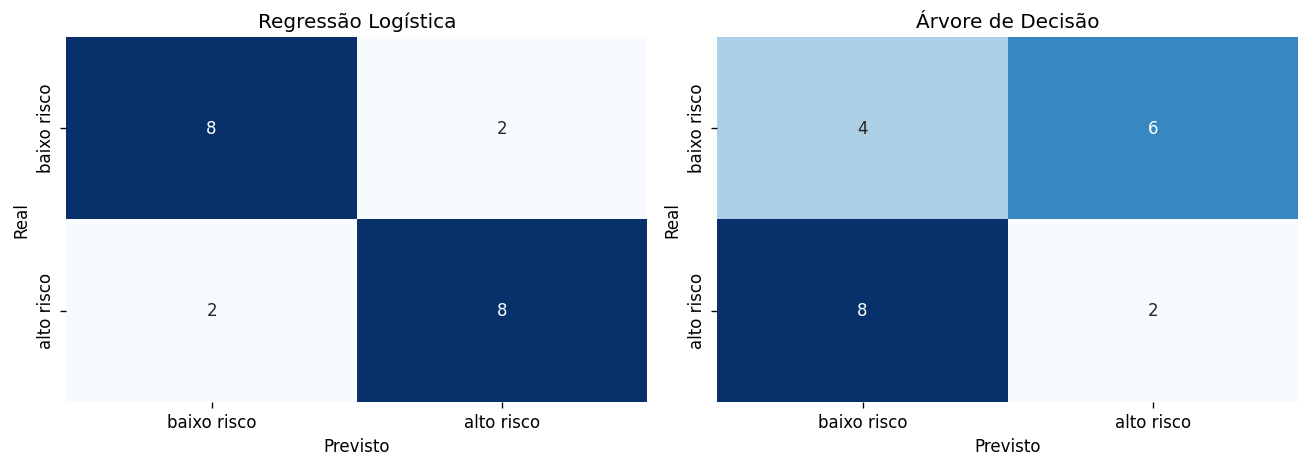

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
for eixo, (nome, item) in zip(eixos, resultados.items()):
    sns.heatmap(item["matriz"], annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["baixo risco", "alto risco"],
                yticklabels=["baixo risco", "alto risco"], ax=eixo)
    eixo.set_title(nome)
    eixo.set_xlabel("Previsto")
    eixo.set_ylabel("Real")
plt.tight_layout()
fig.savefig(FIGURAS / "matrizes_confusao.png", dpi=180, bbox_inches="tight")
plt.show()


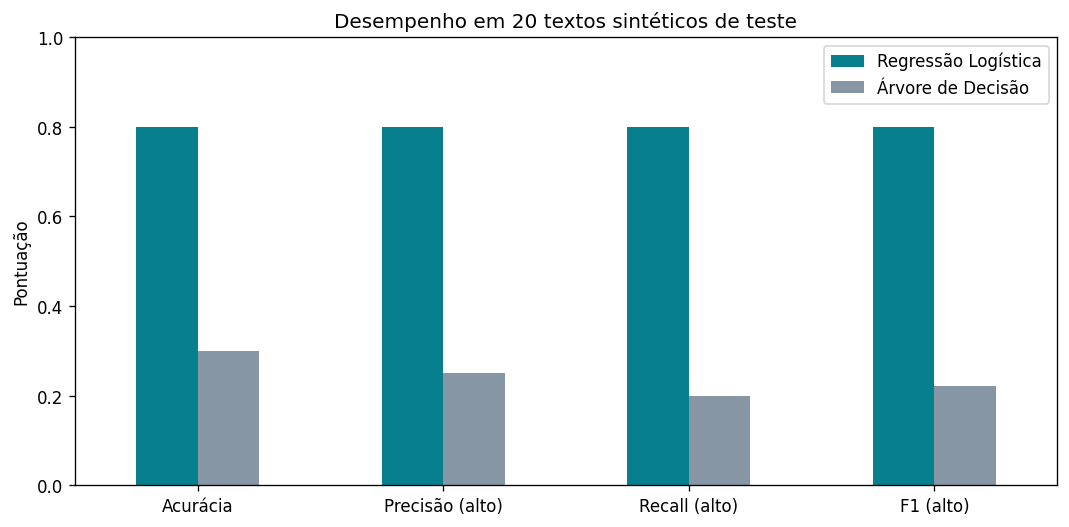

In [8]:
fig, eixo = plt.subplots(figsize=(9, 4.5))
tabela_metricas.rename(columns={
    "acuracia": "Acurácia", "precisao_alto_risco": "Precisão (alto)",
    "recall_alto_risco": "Recall (alto)", "f1_alto_risco": "F1 (alto)",
}).T.plot.bar(ax=eixo, color=["#087f8c", "#8796a5"], rot=0)
eixo.set_ylim(0, 1)
eixo.set_ylabel("Pontuação")
eixo.set_title("Desempenho em 20 textos sintéticos de teste")
eixo.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIGURAS / "comparacao_modelos.png", dpi=180, bbox_inches="tight")
plt.show()


### Testes com frases inéditas


In [9]:
modelo_escolhido = MODELO_DEMONSTRACAO
pipeline_final = pipelines[modelo_escolhido]
frases_ineditas = [
    "Estou com aperto forte no peito, suor frio e dificuldade para respirar.",
    "Senti tensão leve no ombro depois da academia e consigo trabalhar normalmente.",
    "Minha fala ficou enrolada e perdi a força de um lado do corpo.",
    "Não sinto dor no peito, apenas desconforto muscular ao mover o braço.",
]
demonstracao = pd.DataFrame({"frase": frases_ineditas, "previsao": pipeline_final.predict(frases_ineditas)})
print("Demonstração qualitativa: estas quatro frases não entram nas métricas de teste.")
demonstracao


Demonstração qualitativa: estas quatro frases não entram nas métricas de teste.


,frase,previsao
0,"Estou com aperto forte no peito, suor frio e d...",alto risco
1,Senti tensão leve no ombro depois da academia ...,baixo risco
2,Minha fala ficou enrolada e perdi a força de u...,baixo risco
3,"Não sinto dor no peito, apenas desconforto mus...",baixo risco


## Continuidade com a Fase 1

O dataset tabular de 150 registros × 17 variáveis da Fase 1 não foi usado como treino deste classificador textual. A auditoria abaixo registra o reaproveitamento efetivo dos artefatos, sem confundir dados tabulares, textos e imagens ECG com o CSV textual novo. O JSON é produzido por `python src/auditar_continuidade_fase1.py` quando o repositório completo está disponível.


In [10]:
arquivo_continuidade = RAIZ / "data" / "processed" / "continuidade_fase1.json"
if arquivo_continuidade.exists():
    continuidade = json.loads(arquivo_continuidade.read_text(encoding="utf-8"))
    tabela_fase1 = continuidade["tabela"]
    print(f"Fase 1: {tabela_fase1['registros']} registros × {len(tabela_fase1['colunas'])} variáveis")
    print("Rótulos originais:", tabela_fase1["rotulos_originais"])
    print("CSV textual da Fase 2 deriva do CSV da Fase 1:", continuidade["experimento_classificacao_fase2"]["derivado_do_csv_fase1"])
    print("Textos contextuais reaproveitados: frequência de termos, sem treinamento do classificador.")
    resumo_textos = pd.DataFrame([{
        "arquivo": Path(texto["fonte"]["caminho"]).name,
        "tokens_filtrados": texto["tokens_apos_filtragem"],
        "termos_distintos": texto["termos_distintos"],
    } for texto in continuidade["nlp"]["textos"]])
    print(resumo_textos.to_string(index=False))
else:
    print("Auditoria de continuidade ainda não gerada; executar src/auditar_continuidade_fase1.py.")


Fase 1: 150 registros × 17 variáveis
Rótulos originais: {'higher_simulated_risk': 7, 'lower_simulated_risk': 143}
CSV textual da Fase 2 deriva do CSV da Fase 1: False
Textos contextuais reaproveitados: frequência de termos, sem treinamento do classificador.
                                        arquivo  tokens_filtrados  termos_distintos
texto_01_disturbances_of_the_heart_contexto.txt                58                52
      texto_02_lettsomian_lectures_contexto.txt                54                46


## Conclusões e limitações

- A comparação considera o **recall de alto risco**, não apenas a acurácia.
- O teste contém 20 textos, mas apenas 10 grupos-base independentes: duas variações do mesmo grupo não equivalem a dois casos independentes.
- A escolha da Regressão Logística para demonstração é fixa; os números comparativos do teste não substituem validação externa nem uma seleção de modelos em validação própria.
- A base é pequena, sintética e contém padrões construídos; o desempenho não pode ser generalizado para pacientes reais.
- TF-IDF não interpreta adequadamente contexto, negação, intensidade ou temporalidade em todos os casos.
- Uma aplicação real exigiria dados clínicos representativos, validação externa, supervisão médica, governança e avaliação regulatória.

> **Aviso:** resultado educacional; não constitui diagnóstico médico.
